In [3]:
# %pip install pandas
# %pip install numpy
# %pip install matplotlib
# %pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline



## Load dataset

In [4]:
csv_path = "./data/Loan_Default.csv"
df = pd.read_csv(csv_path)
df.head(5)

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


# Exploratory Data Analysis

In [5]:
df.shape

(148670, 34)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [7]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [8]:
df['Status'].value_counts()

Status
0    112031
1     36639
Name: count, dtype: int64

In [12]:
import pandas as pd
import numpy as np
import scipy.stats as stats

results = []

cat_cols = [
    'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
    'loan_purpose', 'Credit_Worthiness', 'open_credit',
    'business_or_commercial', 'Neg_ammortization', 'interest_only',
    'lump_sum_payment', 'construction_type', 'occupancy_type',
    'Secured_by', 'credit_type', 'co-applicant_credit_type',
    'submission_of_application', 'Region', 'Security_Type', 'Status'
]

num_cols = [
    'ID', 'year', 'loan_amount', 'rate_of_interest',
    'Interest_rate_spread', 'Upfront_charges', 'term',
    'property_value', 'total_units', 'income', 'Credit_Score',
    'age', 'LTV', 'dtir1'
]


# --- Catégorielles ---
for col in cat_cols:
    contingency = pd.crosstab(df[col], df['Status'])
    chi2, p, dof, ex = stats.chi2_contingency(contingency)
    results.append({
        "Column": col,
        "Test": "Chi-square",
        "Score": chi2,
        "p_value": p,
        "dof": dof
    })

# --- Numériques ---
for col in num_cols:
    valid = df[[col,'Status']].dropna()
    if valid[col].dtype.kind in 'bifc':
        # Vérifier qu'il y a de la variance dans les deux colonnes
        if valid[col].nunique() > 1 and valid['Status'].nunique() > 1:
            corr, pval = stats.pearsonr(valid[col], valid['Status'])
        else:
            corr, pval = np.nan, np.nan
        results.append({
            "Column": col,
            "Test": "Correlation",
            "Score": corr,
            "p_value": pval,
            "dof": np.nan
        })

importance_df = pd.DataFrame(results)
importance_df['AbsScore'] = importance_df['Score'].abs()
importance_df = importance_df.sort_values('AbsScore', ascending=False)

display(importance_df)


,Column,Test,Score,p_value,dof,AbsScore
19,Status,Chi-square,148664.615307,0.000000e+00,1.0,148664.615307
14,credit_type,Chi-square,52135.280705,0.000000e+00,3.0,52135.280705
10,lump_sum_payment,Chi-square,5237.827442,0.000000e+00,1.0,5237.827442
8,Neg_ammortization,Chi-square,3610.208104,0.000000e+00,1.0,3610.208104
15,co-applicant_credit_type,Chi-square,3092.392571,0.000000e+00,1.0,3092.392571
16,submission_of_application,Chi-square,2171.709755,0.000000e+00,1.0,2171.709755
3,loan_type,Chi-square,1309.958143,3.517253e-285,2.0,1309.958143
7,business_or_commercial,Chi-square,1272.807998,9.172191e-279,1.0,1272.807998
1,Gender,Chi-square,1043.600850,6.260048e-226,3.0,1043.600850
0,loan_limit,Chi-square,427.398487,5.985647e-95,1.0,427.398487


Résumé EDA
Les tests montrent que certaines variables catégorielles ont une association très forte avec le statut du prêt.

Les variables financières numériques apportent une corrélation crédible avec la capacité de remboursement.

Les variables démographiques et contextuelles enrichissent l’analyse mais doivent être utilisées avec discernement.

👉 En pratique, les colonnes retenues (loan_type, Neg_ammortization, loan_purpose, rate_of_interest, property_value, LTV, dtir1, income, loan_amount) offrent un équilibre entre pertinence statistique et validité métier, permettant de construire un modèle robuste pour la détection des prêts risqués.

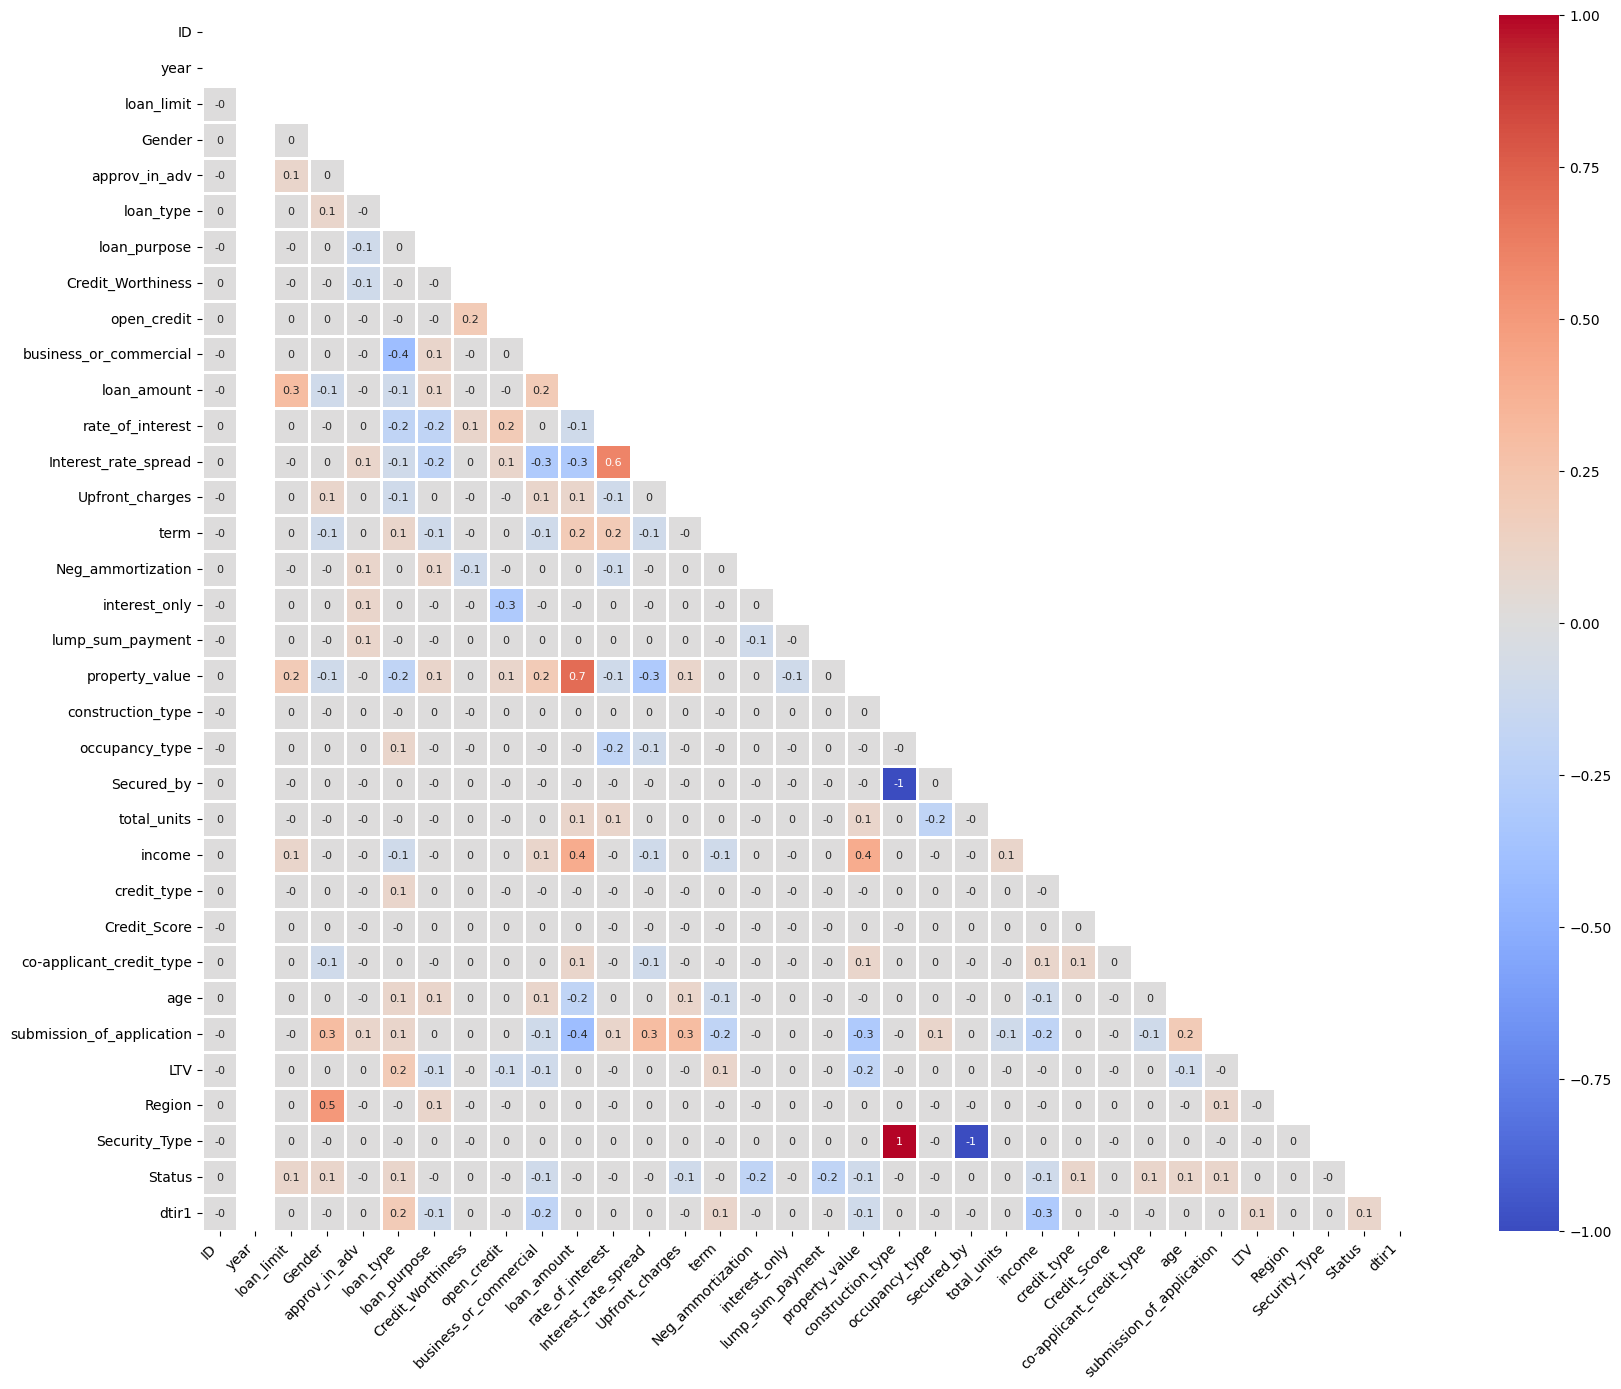

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# --- Step 1: Copy DataFrame to avoid modifying original ---
df_encoded = df.copy()

# --- Step 2: Encode categorical (string/object) columns ---
for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = df_encoded[col].astype(str)  # ensure strings
    df_encoded[col] = le.fit_transform(df_encoded[col])

# --- Step 3: Handle missing values ---
for col in df_encoded.columns:
    if df_encoded[col].dtype in [np.float64, np.int64]:
        df_encoded[col] = df_encoded[col].fillna(df_encoded[col].median())
    else:
        df_encoded[col] = df_encoded[col].fillna(df_encoded[col].mode()[0])

# --- Step 4: Compute correlation matrix ---
corr_matrix = df_encoded.corr()

# --- Step 5: Round values (e.g. 0.0007 → 0.0, 0.57 → 0.6) ---
corr_matrix = corr_matrix.round(1)

# --- Step 6: Replace diagonal with 0 (or NaN to leave blank) ---
np.fill_diagonal(corr_matrix.values, 0)

# --- Step 7: Mask upper triangle to reduce density ---
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# --- Step 8: Plot heatmap ---
plt.figure(figsize=(18,14))  # Larger canvas
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            cmap='coolwarm', 
            annot_kws={"size":8}, 
            linewidths=1, 
            linecolor='white', 
            square=True)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


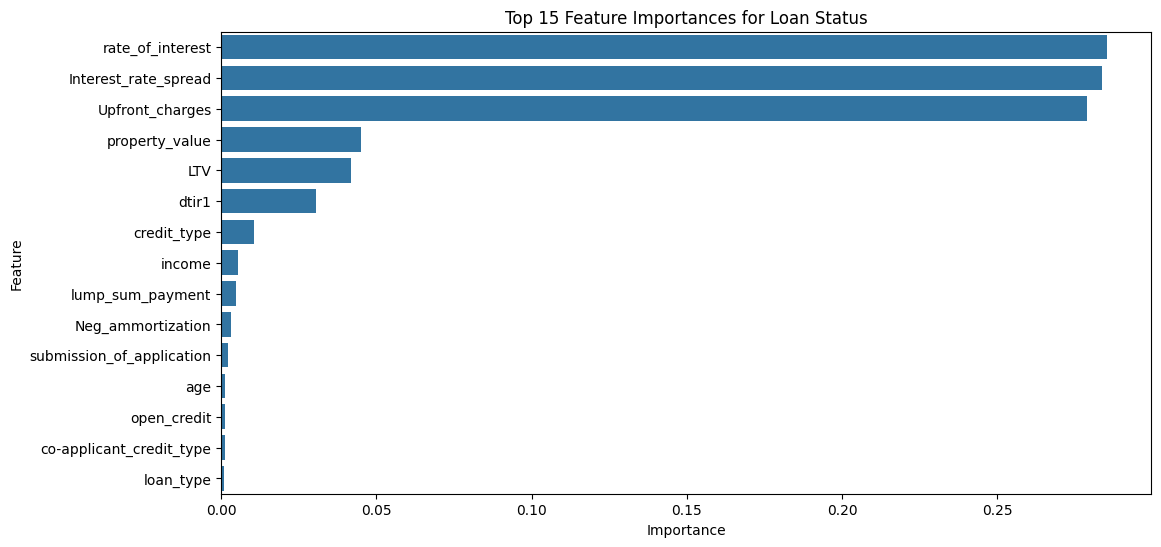

In [23]:
# %pip install scikit-learn

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier


import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

# Encode categorical variables
df_encoded = df.copy()
for col in df.select_dtypes(include=['object']).columns:
    df_encoded[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Split data
X = df_encoded.drop('Status', axis=1)
y = df_encoded['Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Feature importance
importances = model.feature_importances_
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

# Plot top 15
plt.figure(figsize=(12,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(15))
plt.title("Top 15 Feature Importances for Loan Status")
plt.show()

In [36]:
# Sort by importance
feature_importance = feature_importance.sort_values('Importance', ascending=False)

# Relative threshold: keep features >= 5% of max importance
threshold = 0 * feature_importance['Importance'].max()
selected_features = feature_importance[feature_importance['Importance'] >= threshold]

print("Selected features:")
display(selected_features.sort_values(by="Importance", ascending=False))



Selected features:


,Feature,Importance
11,rate_of_interest,2.853646e-01
12,Interest_rate_spread,2.838257e-01
13,Upfront_charges,2.788434e-01
18,property_value,4.501674e-02
29,LTV,4.190420e-02
32,dtir1,3.065991e-02
24,credit_type,1.053219e-02
23,income,5.336634e-03
17,lump_sum_payment,4.666518e-03
15,Neg_ammortization,3.267179e-03


In [45]:
# le nombre des valeurs na
display(df[[
'loan_type', 'Neg_ammortization', 'loan_purpose',
'rate_of_interest',
'Upfront_charges',
'Credit_Score',
'Interest_rate_spread',
'property_value','LTV','dtir1','income','loan_amount'
]].isna().sum())

loan_type                   0
Neg_ammortization         121
loan_purpose              134
rate_of_interest        36439
Upfront_charges         39642
Interest_rate_spread    36639
property_value          15098
LTV                     15098
dtir1                   24121
income                   9150
loan_amount                 0
dtype: int64

In [17]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, accuracy_score, mean_squared_error, make_scorer, f1_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

# -----------------------------
# features
# -----------------------------
cat_cols = ['loan_type', 'Neg_ammortization', 'loan_purpose']
num_cols = [ 
    # 'Upfront_charges',
    'rate_of_interest',
    # 'Credit_Score',
    # 'Interest_rate_spread',
    'property_value','LTV','dtir1','income','loan_amount']



X = df[cat_cols + num_cols]
y = df['Status']

# -----------------------------
# Train/test split
# -----------------------------
X_train_full, X_test_final, y_train_full, y_test_final = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.3, stratify=y_train_full, random_state=42
)

print("Split Train from Test")

# -----------------------------
# Preprocessing
# -----------------------------
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

# -----------------------------
# Definition des models
# -----------------------------
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=5000, solver='saga', class_weight='balanced'
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight='balanced'
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

precision = make_scorer(precision_score, zero_division=0)
recall    = make_scorer(recall_score,    zero_division=0)
accuracy  = make_scorer(accuracy_score)
f1        = make_scorer(f1_score,        zero_division=0)

def rmse_scorer(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
rmse = make_scorer(rmse_scorer, greater_is_better=False)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# Evaluation des models
# -----------------------------
results = []
for name, model in models.items():
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('model', model)])
    
    prec_cv  = cross_val_score(clf, X_train, y_train, cv=cv, scoring=precision).mean()
    rec_cv   = cross_val_score(clf, X_train, y_train, cv=cv, scoring=recall).mean()
    acc_cv   = cross_val_score(clf, X_train, y_train, cv=cv, scoring=accuracy).mean()
    f1_cv    = cross_val_score(clf, X_train, y_train, cv=cv, scoring=f1).mean()
    rmse_cv  = abs(cross_val_score(clf, X_train, y_train, cv=cv, scoring=rmse).mean())

    clf.fit(X_train, y_train)
    y_val_pred = clf.predict(X_val)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1  = f1_score(y_val, y_val_pred, zero_division=0)

    results.append([name, prec_cv, rec_cv, acc_cv, f1_cv, rmse_cv, val_acc, val_f1])

results_df = pd.DataFrame(results, columns=[
    "Model", "CV Precision", "CV Recall", "CV Accuracy", "CV F1", "CV RMSE", "Validation Accuracy", "Validation F1"
])

display(results_df)


Split Train from Test


,Model,CV Precision,CV Recall,CV Accuracy,CV F1,CV RMSE,Validation Accuracy,Validation F1
0,Logistic Regression,0.306432,0.480588,0.603888,0.374229,0.629368,0.603632,0.374842
1,Random Forest,0.861586,0.826937,0.924596,0.843876,0.274593,0.925883,0.846674
2,Gradient Boosting,0.834530,0.847991,0.921069,0.841154,0.280942,0.922584,0.843651


les résultats parfaits étaient dus à une fuite, mais après suppression des variables sensibles, les modèles d’ensemble offrent une performance fiable, avec Gradient Boosting privilégié pour limiter les défauts non détectés.

In [16]:
# -----------------------------
# Test final de Gradient Boosting
# -----------------------------
gb_clf = Pipeline(steps=[('preprocessor', preprocessor),
                         ('model', GradientBoostingClassifier(random_state=42))])

gb_clf.fit(X_train_full, y_train_full)
y_test_pred = gb_clf.predict(X_test_final)

test_acc     = accuracy_score(y_test_final, y_test_pred)
test_f1      = f1_score(y_test_final, y_test_pred, zero_division=0)
test_prec    = precision_score(y_test_final, y_test_pred, zero_division=0)
test_rec     = recall_score(y_test_final, y_test_pred, zero_division=0)
test_rmse    = np.sqrt(mean_squared_error(y_test_final, y_test_pred))

print("Gradient Boosting Test Results")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test F1       : {test_f1:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall   : {test_rec:.4f}")
print(f"Test RMSE     : {test_rmse:.4f}")


Gradient Boosting Test Results
Test Accuracy : 0.9226
Test F1       : 0.8446
Test Precision: 0.8361
Test Recall   : 0.8533
Test RMSE     : 0.2782


Après validation, Gradient Boosting apparaît bien calibré pour la détection des prêts risqués : il réduit efficacement les faux négatifs tout en maintenant une précision satisfaisante. C’est donc le modèle à privilégier pour ton cas d’usage.

In [20]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, accuracy_score, mean_squared_error
import numpy as np
import joblib


cat_cols = ['loan_type', 'Neg_ammortization', 'loan_purpose']
num_cols = ['rate_of_interest','property_value','LTV','dtir1','income','loan_amount']


numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)


best_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(n_estimators=200, random_state=42))
])

# -----------------------------
# Training X_train
# -----------------------------
best_model.fit(X_train, y_train)

# -----------------------------
# Validation X_val
# -----------------------------
y_val_pred = best_model.predict(X_val)

print("Validation Precision:", precision_score(y_val, y_val_pred, zero_division=0))
print("Validation Recall:", recall_score(y_val, y_val_pred))
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))

# -----------------------------
# Sauvegarder la pipeline
# -----------------------------
joblib.dump(best_model, "./data/GradientBoostingClassifier_LOANS_STATUS.pkl")
print("Model saved as GradientBoostingClassifier_LOANS_STATUS.pkl")


Validation Precision: 0.8563521349499209
Validation Recall: 0.8445541980764232
Validation Accuracy: 0.9267800518881522
Validation RMSE: 0.2705918478296192
Model saved as GradientBoostingClassifier_LOANS_STATUS.pkl
